In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

In [23]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(DATA_PATH)

In [24]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9551, 20)


#### UNIVARIATE ANALYSIS

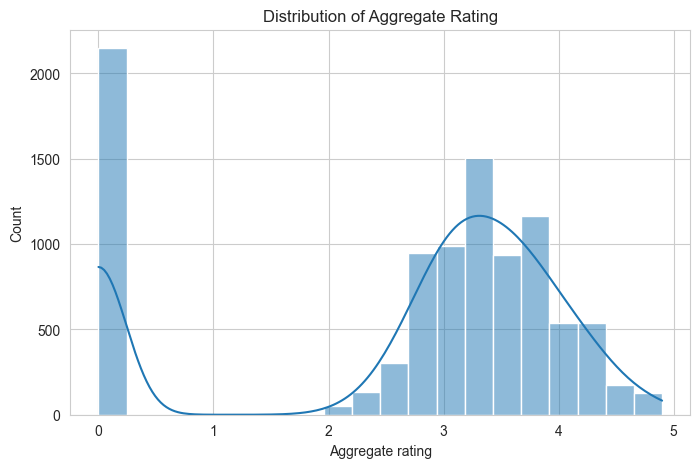

Restaurants with 0 Rating: 2148
Percentage of 0 rating: 22.489791644853945


In [25]:
# 1. Distribution of Aggregate Rating
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Rating")
plt.show()

print("Restaurants with 0 Rating:",
      (df['Aggregate rating'] == 0).sum())
print("Percentage of 0 rating:",
      (df['Aggregate rating'] == 0).mean() * 100)

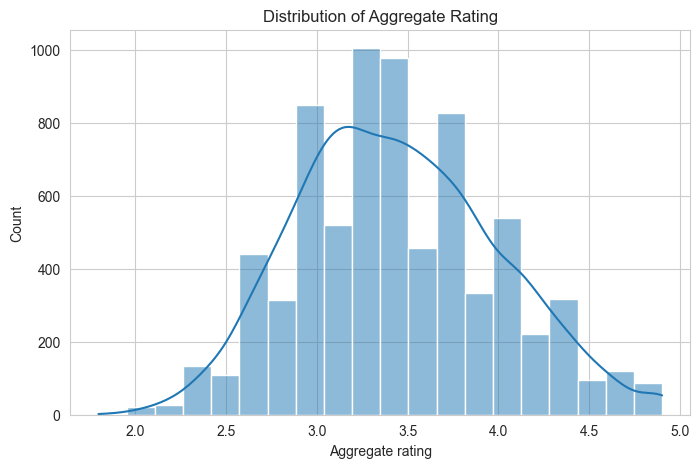

Restaurants with 0 Rating: 0
Percentage of 0 rating: 0.0


In [26]:
rated_df = df[df['Aggregate rating'] > 0]

# 1. Distribution of Aggregate Rating
plt.figure(figsize=(8,5))
sns.histplot(rated_df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Rating")
plt.show()

print("Restaurants with 0 Rating:",
      (rated_df['Aggregate rating'] == 0).sum())
print("Percentage of 0 rating:",
      (rated_df['Aggregate rating'] == 0).mean() * 100)

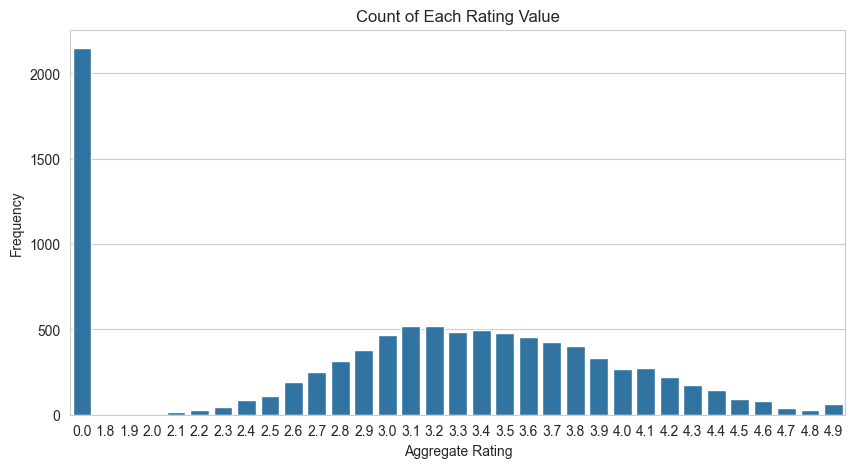

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Aggregate rating')
plt.title("Count of Each Rating Value")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.show()

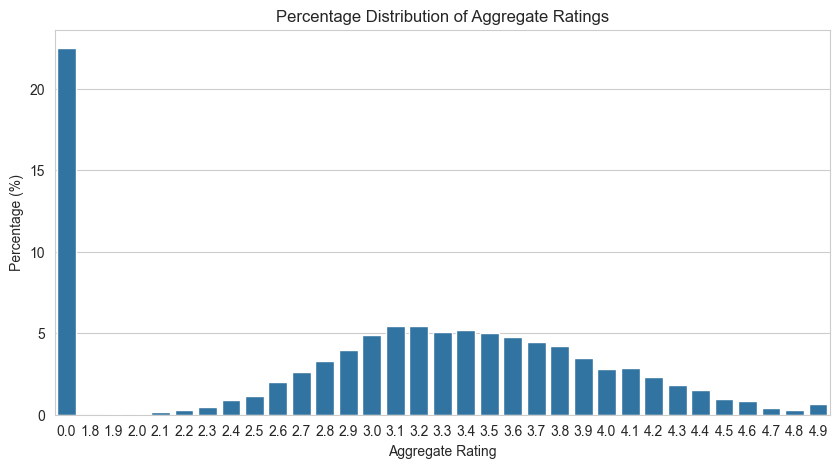

In [28]:
rating_counts = df['Aggregate rating'].value_counts().sort_index()
rating_percent = (rating_counts / len(df)) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=rating_counts.index, y=rating_percent)
plt.title("Percentage Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Percentage (%)")
plt.show()

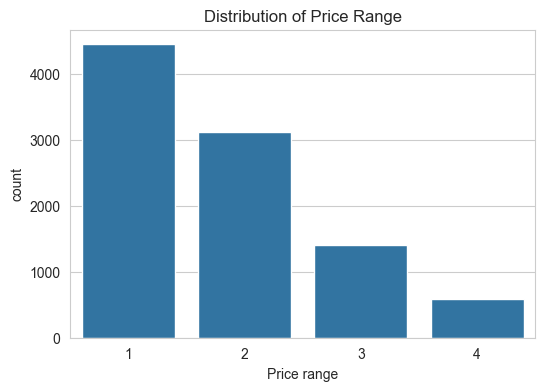

In [29]:
# 2. Distribution of Price Range
plt.figure(figsize=(6,4))
sns.countplot(x='Price range', data=df)
plt.title("Distribution of Price Range")
plt.show()

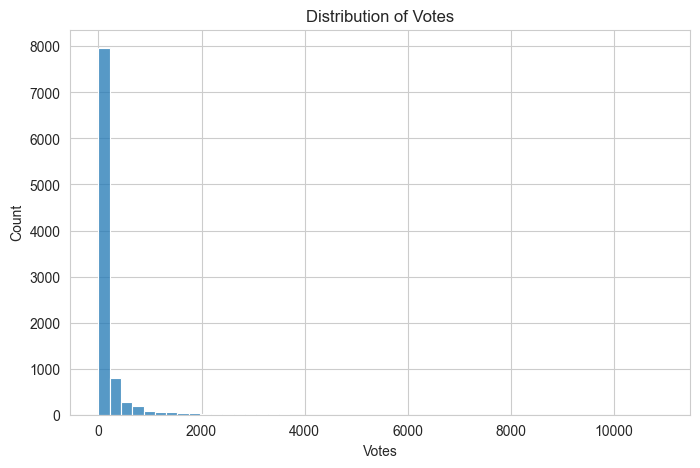

Votes Skewness: 8.80763668770947


In [30]:
# 3. Distribution of Votes
plt.figure(figsize=(8,5))
sns.histplot(df['Votes'], bins=50)
plt.title("Distribution of Votes")
plt.show()

print("Votes Skewness:", df['Votes'].skew())

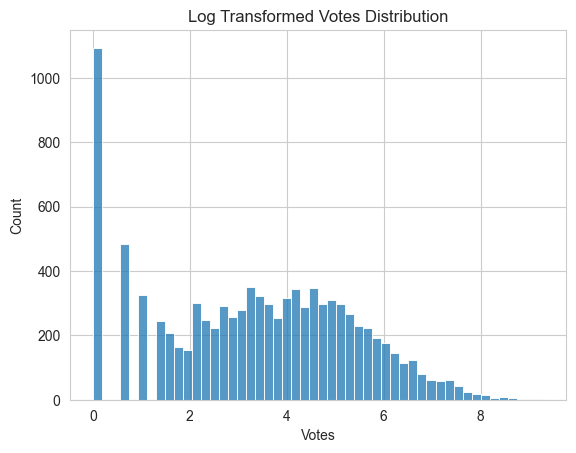

In [31]:
sns.histplot(np.log1p(df['Votes']), bins=50)
plt.title("Log Transformed Votes Distribution")
plt.show()

C:\Users\venut\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


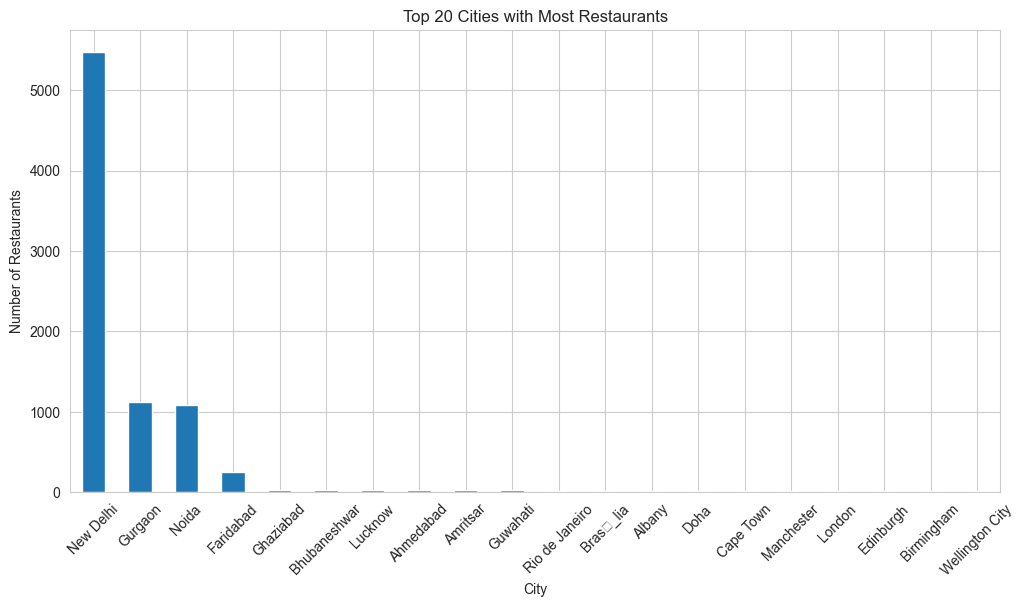

In [32]:
# 4. Top Cities
top_cities = df['City'].value_counts().head(20)

plt.figure(figsize=(12,6))
top_cities.plot(kind='bar')
plt.title("Top 20 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

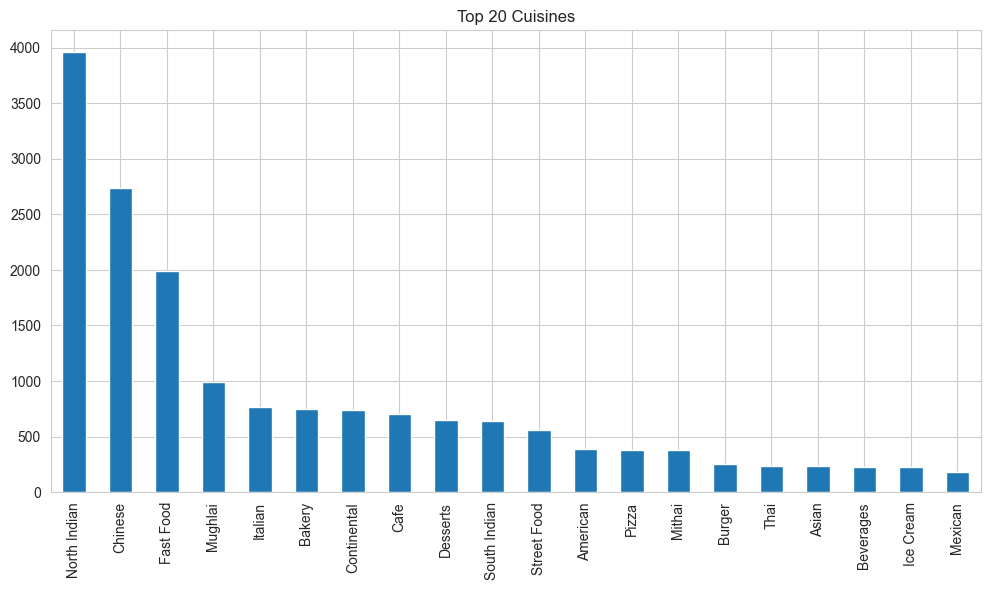

In [33]:
# 5. Top Cuisines
cuisine_split = df['Cuisines'].str.split(', ', expand=True).stack()
top_cuisines = cuisine_split.value_counts().head(20)

plt.figure(figsize=(12,6))
top_cuisines.plot(kind='bar')
plt.title("Top 20 Cuisines")
plt.show()

In [34]:
print("Cost Skewness:", df['Average Cost for two'].skew())

Cost Skewness: 35.477914900871255


#### BIVARIATE ANALYSIS

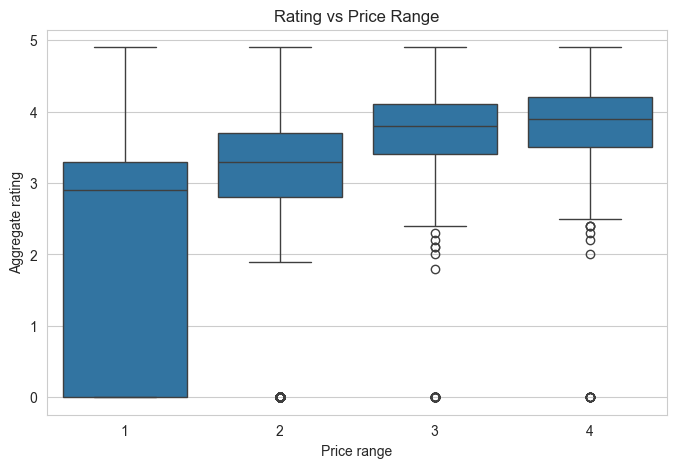

In [35]:
# 1. Rating vs Price Range
plt.figure(figsize=(8,5))
sns.boxplot(x='Price range', y='Aggregate rating', data=df)
plt.title("Rating vs Price Range")
plt.show()

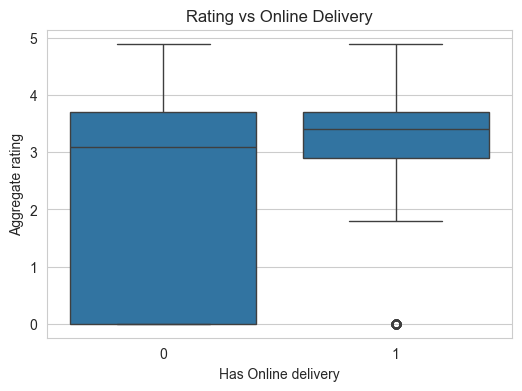

In [36]:
# 2. Rating vs Online Delivery
plt.figure(figsize=(6,4))
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df)
plt.title("Rating vs Online Delivery")
plt.show()

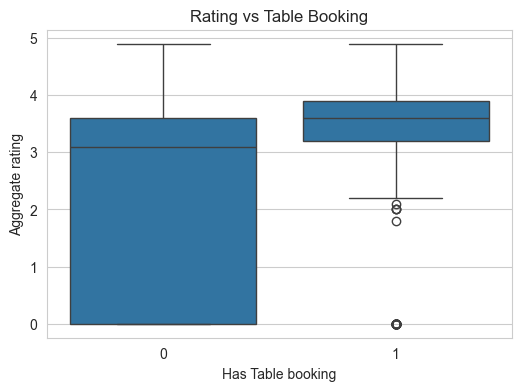

In [37]:
# 3. Rating vs Table Booking
plt.figure(figsize=(6,4))
sns.boxplot(x='Has Table booking', y='Aggregate rating', data=df)
plt.title("Rating vs Table Booking")
plt.show()

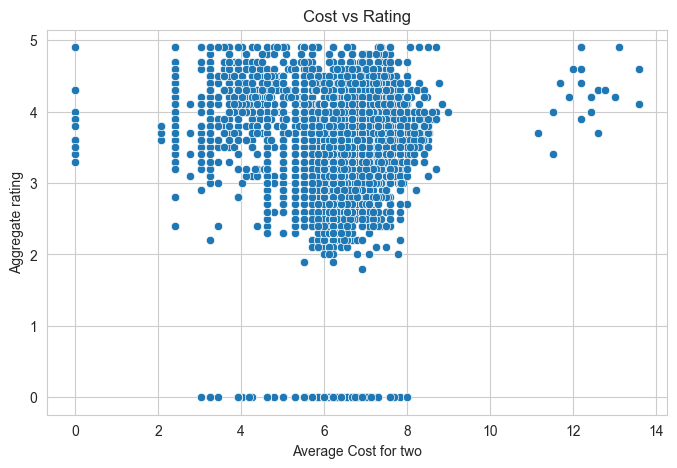

In [38]:
# 4. Cost vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(x=np.log1p(df['Average Cost for two']), 
                y=df['Aggregate rating'])
plt.title("Cost vs Rating")
plt.show()

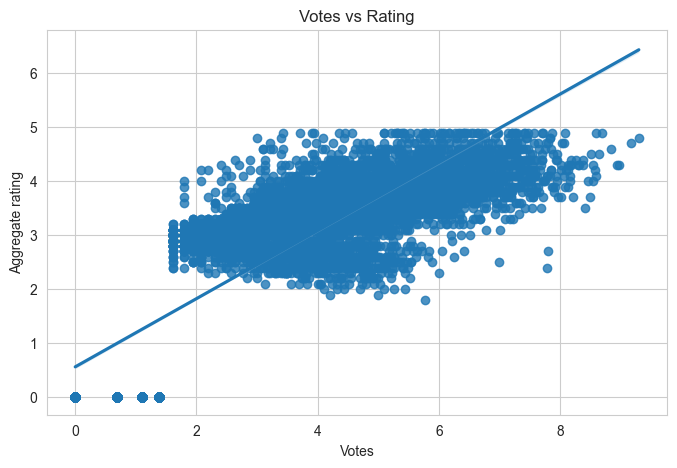

In [39]:
# 5. Votes vs Rating
plt.figure(figsize=(8,5))
sns.regplot(x=np.log1p(df['Votes']), 
            y=df['Aggregate rating'])
plt.title("Votes vs Rating")
plt.show()

#### MULTIVARIANT ANALYSIS

In [40]:
corr_lat = df['Latitude'].corr(df['Aggregate rating'])
corr_lon = df['Longitude'].corr(df['Aggregate rating'])

print("Correlation between Latitude and Rating:", corr_lat)
print("Correlation between Longitude and Rating:", corr_lon)

Correlation between Latitude and Rating: 0.000515580690236031
Correlation between Longitude and Rating: -0.1168175773454043


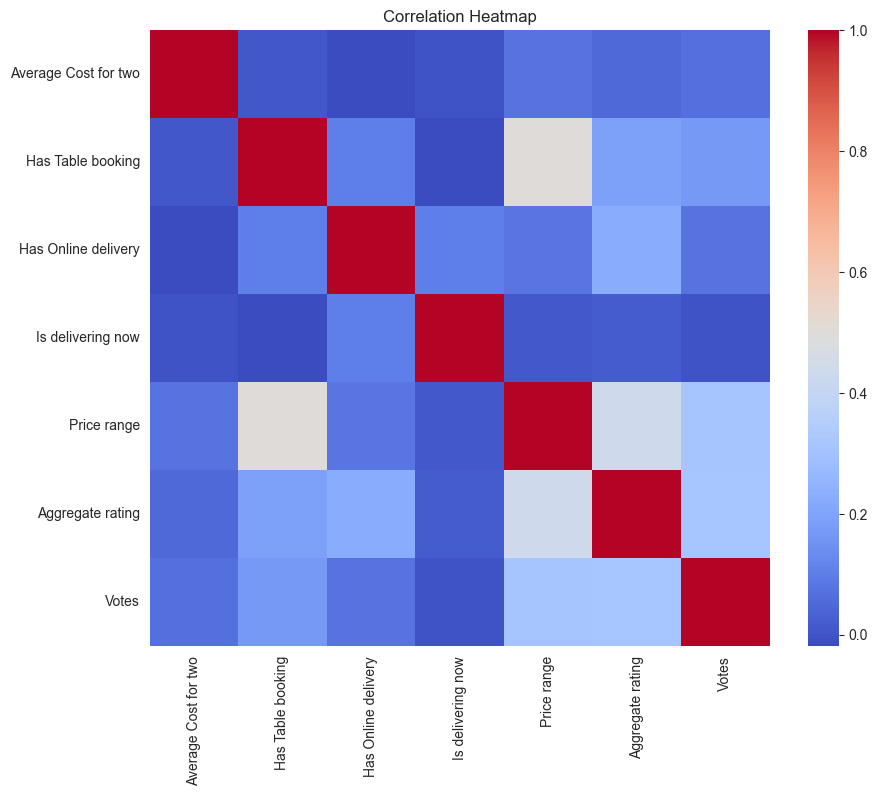

In [41]:
# Correlation Heatmap

num_cols = df.select_dtypes(include = [np.number]).columns
exclude_cols = ['Restaurant ID', 'Country Code', 'Latitude', 'Longitude']
num_cols = [col for col in num_cols if col not in exclude_cols]

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [42]:
# Grouped Mean Ratings
grouped_price = df.groupby("Price range")["Aggregate rating"].mean()
print("\nAverage Rating by Price Range:\n", grouped_price)

grouped_delivery = df.groupby("Has Online delivery")["Aggregate rating"].mean()
print("\nAverage Rating by Online Delivery:\n", grouped_delivery)

grouped_booking = df.groupby("Has Table booking")["Aggregate rating"].mean()
print("\nAverage Rating by Table Booking:\n", grouped_booking)

grouped_votes = df.groupby(
    pd.qcut(df['Votes'], 4),
    observed=False
)['Aggregate rating'].mean()
print("\nAverage Rating by Votes Quartiles:\n", grouped_votes)

grouped_country = df.groupby('Country Code')['Aggregate rating'].mean()
print("\nAverage Rating by Country Code:\n", grouped_country)


Average Rating by Price Range:
 Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

Average Rating by Online Delivery:
 Has Online delivery
0    2.465296
1    3.248837
Name: Aggregate rating, dtype: float64

Average Rating by Table Booking:
 Has Table booking
0    2.559359
1    3.441969
Name: Aggregate rating, dtype: float64

Average Rating by Votes Quartiles:
 Votes
(-0.001, 5.0]       0.434696
(5.0, 31.0]         3.101558
(31.0, 131.0]       3.393995
(131.0, 10934.0]    3.891238
Name: Aggregate rating, dtype: float64

Average Rating by Country Code:
 Country Code
1      2.523324
14     3.658333
30     3.763333
37     3.575000
94     4.295238
148    4.262500
162    4.468182
166    4.060000
184    3.575000
189    4.210000
191    3.870000
208    4.300000
214    4.233333
215    4.087500
216    4.004378
Name: Aggregate rating, dtype: float64
